In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

# טען את הנתונים
df = pd.read_csv("/home/framg/dev/anomalitor/data/nasa/processed/set1_features.csv")

# צור תווית אנומליה (1 = חריג, 0 = תקין)
df['is_anomaly'] = (df['ratio'] > 1.2).astype(int)

print(df['is_anomaly'].value_counts())
print(df.head())

is_anomaly
0    2116
1      40
Name: count, dtype: int64
             timestamp    rms_b1    rms_b3     ratio  is_anomaly
0  2003.10.22.12.06.24  0.124614  0.128887  1.034292           0
1  2003.10.22.12.09.13  0.123811  0.129562  1.046449           0
2  2003.10.22.12.14.13  0.125246  0.131339  1.048644           0
3  2003.10.22.12.19.13  0.125197  0.131083  1.047008           0
4  2003.10.22.12.24.13  0.125618  0.131307  1.045290           0


In [3]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# הגדר פיצ'רים (X) ומטרה (y)
features = ['rms_b1', 'rms_b3']
target = 'ratio'

# הפרד נתונים תקינים וחריגים
df_normal = df[df['is_anomaly'] == 0]
df_anomaly = df[df['is_anomaly'] == 1]

# אימון על נתונים תקינים בלבד
X_train, X_test, y_train, y_test = train_test_split(
    df_normal[features], df_normal[target], test_size=0.2, random_state=42
)

model = RandomForestRegressor(n_estimators=25, random_state=42)
model.fit(X_train, y_train)

print("Train R²:", model.score(X_train, y_train))
print("Test R² (normal only):", model.score(X_test, y_test))

Train R²: 0.9993746256052388
Test R² (normal only): 0.9958081059547752


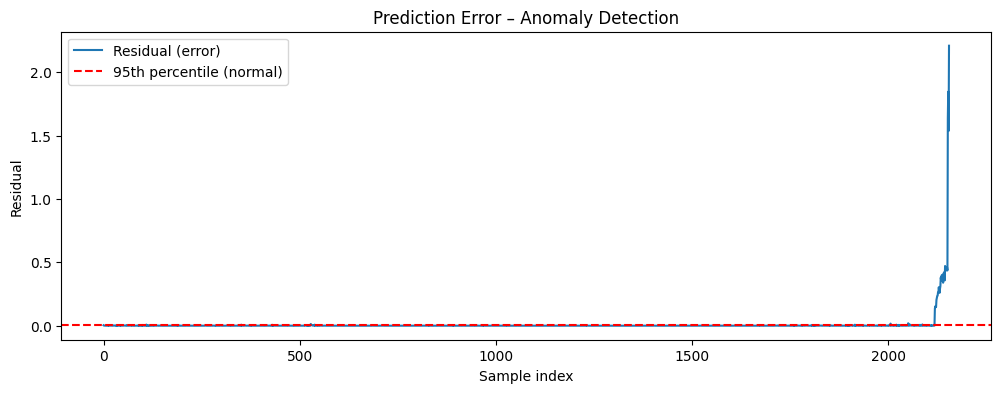

In [4]:
# חיזוי על כל הטבלה
df['predicted_ratio'] = model.predict(df[features])

# residual = |actual - predicted|
df['residual'] = np.abs(df['ratio'] - df['predicted_ratio'])

# גרף residual לאורך זמן
plt.figure(figsize=(12,4))
plt.plot(df['residual'], label='Residual (error)')
plt.axhline(y=df[df['is_anomaly']==0]['residual'].quantile(0.95), 
            color='r', linestyle='--', label='95th percentile (normal)')
plt.xlabel('Sample index')
plt.ylabel('Residual')
plt.legend()
plt.title('Prediction Error – Anomaly Detection')
plt.show()

In [5]:
# threshold לפי אחוזון 95 של הרזידואלים על נתונים תקינים
threshold = df[df['is_anomaly'] == 0]['residual'].quantile(0.95)

# זיהוי חריגים
df['detected_anomaly'] = (df['residual'] > threshold).astype(int)

# השוואה בין האמת (is_anomaly) לבין הזיהוי (detected_anomaly)
from sklearn.metrics import classification_report
print(classification_report(df['is_anomaly'], df['detected_anomaly']))

              precision    recall  f1-score   support

           0       1.00      0.95      0.97      2116
           1       0.27      1.00      0.43        40

    accuracy                           0.95      2156
   macro avg       0.64      0.97      0.70      2156
weighted avg       0.99      0.95      0.96      2156



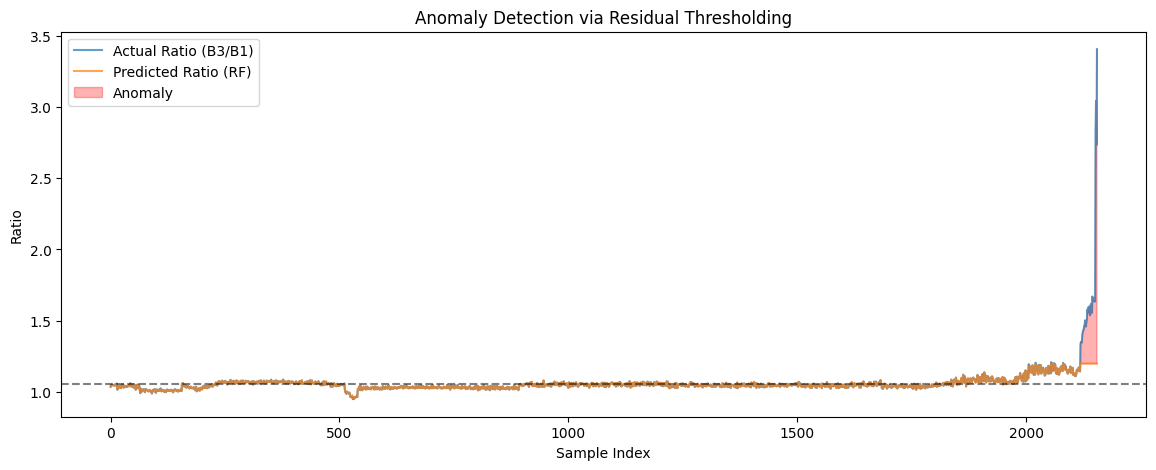

In [6]:
plt.figure(figsize=(14,5))
plt.plot(df['ratio'], label='Actual Ratio (B3/B1)', alpha=0.7)
plt.plot(df['predicted_ratio'], label='Predicted Ratio (RF)', alpha=0.7)
plt.fill_between(df.index, df['ratio'], df['predicted_ratio'], 
                 where=(df['detected_anomaly']==1), color='red', alpha=0.3, label='Anomaly')
plt.axhline(y=threshold + df['predicted_ratio'].mean(), linestyle='--', color='black', alpha=0.5)
plt.xlabel('Sample Index')
plt.ylabel('Ratio')
plt.legend()
plt.title('Anomaly Detection via Residual Thresholding')
plt.show()